In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("churn.csv")

# Drop identifier columns — confirmed in Step 2 as having no predictive value
df_eda = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [3]:
#Overall churn rate
churn_rate = df_eda['Exited'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 20.38%


Overall churn rate: 20.38%

Geography
Germany    32.443204
Spain      16.673395
France     16.174711
Name: Exited, dtype: float64


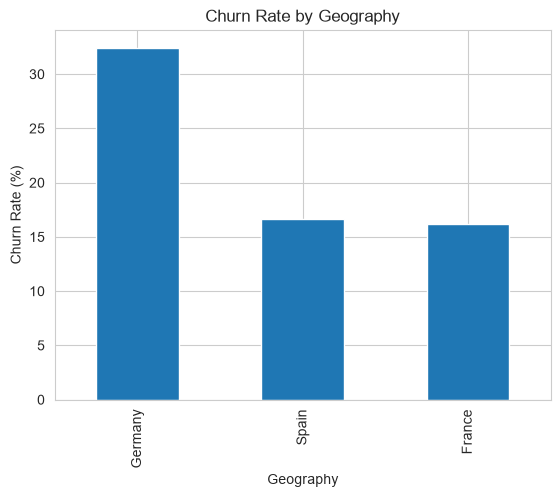

In [4]:
#Churn by Geography
geo_churn = df_eda.groupby('Geography')['Exited'].mean().sort_values(ascending=False) * 100
print(geo_churn)

geo_churn.plot(kind='bar', title='Churn Rate by Geography', ylabel='Churn Rate (%)')
plt.show()

Germany has highest churn @32% followed by spain & france @~16% each

Gender
Female    25.071539
Male      16.474253
Name: Exited, dtype: float64


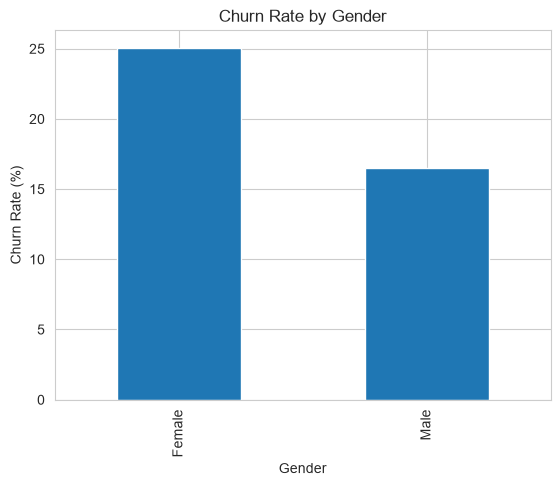

In [5]:
#churn by gender
gender_churn = df_eda.groupby('Gender')['Exited'].mean() * 100
print(gender_churn)

gender_churn.plot(kind='bar', title='Churn Rate by Gender', ylabel='Churn Rate (%)')
plt.show()

Female has high churn rate at 25%

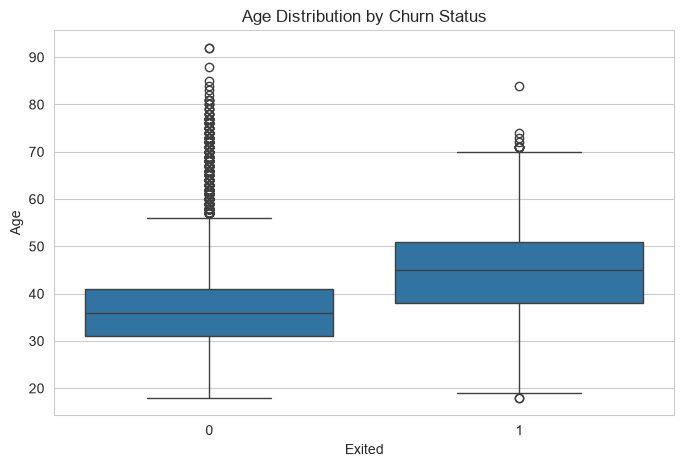

In [6]:
#Age distribution vs churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Age', data=df_eda)
plt.title('Age Distribution by Churn Status')
plt.show()

Churned customers skew notably older - median age ~45 vs. ~37 for retained customers, with the churned group's entire box shifted upward. This contradicts the common assumption that older customers are more loyal; here, mid-to-late 40s customers appear to be a higher-risk age group, not lower-risk.

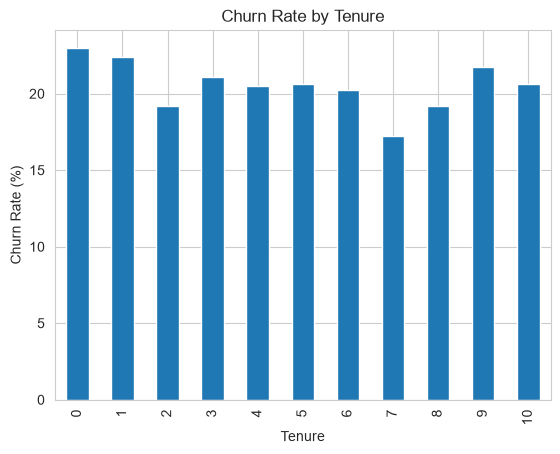

In [7]:
#Tenure Vs Churn
tenure_churn = df_eda.groupby('Tenure')['Exited'].mean() * 100
tenure_churn.plot(kind='bar', title='Churn Rate by Tenure', ylabel='Churn Rate (%)')
plt.show()

In [ ]:
Churn rate is flat across all tenure, no relevance or pattern noted

NumOfProducts
1     27.714398
2      7.603486
3     82.706767
4    100.000000
Name: Exited, dtype: float64


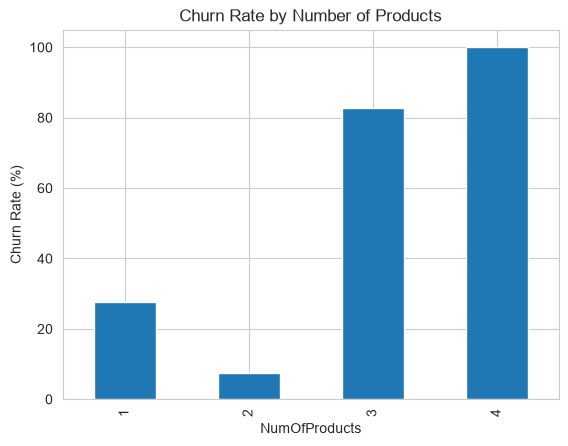

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [18]:
#number of products vs churn
product_churn = df_eda.groupby('NumOfProducts')['Exited'].mean() * 100
print(product_churn)

product_churn.plot(kind='bar', title='Churn Rate by Number of Products', ylabel='Churn Rate (%)')
plt.show()
df_eda['NumOfProducts'].value_counts()

More the products, higher the churn rate. cust with more than 2 products has >80% churn rate. Customer having only 1 product has 27% churn whilst cust with only 2 product has lowest churn at ~7%

IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64


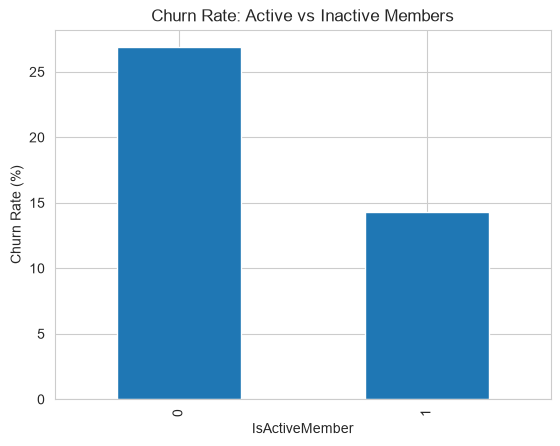

In [9]:
#is active member vs churn
active_churn = df_eda.groupby('IsActiveMember')['Exited'].mean() * 100
print(active_churn)

active_churn.plot(kind='bar', title='Churn Rate: Active vs Inactive Members', ylabel='Churn Rate (%)')
plt.show()

27% churn with inactive members Vs 14% for active ones 

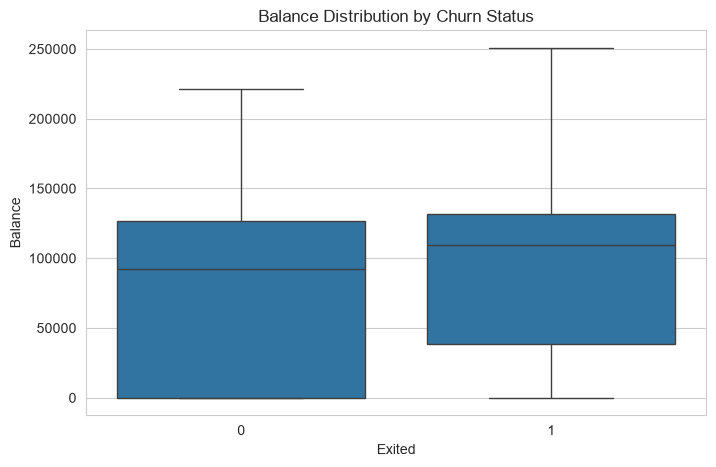

% of customers with zero balance: 36.17%
Churn rate (zero balance): 13.82%
Churn rate (non-zero balance): 24.10%


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,72742.750663,62851.577108,0.0,0.0000,92063.06,126419.3300,221532.80
1,2038.0,91109.476006,58346.483197,0.0,38591.2225,109344.23,131423.6375,250898.09


In [16]:
#balance Vs churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='Balance', data=df_eda)
plt.title('Balance Distribution by Churn Status')
plt.show()

# Zero-balance segment check
zero_balance_pct = (df_eda['Balance'] == 0).mean() * 100
print(f"% of customers with zero balance: {zero_balance_pct:.2f}%")

zero_balance_churn = df_eda[df_eda['Balance'] == 0]['Exited'].mean() * 100
nonzero_balance_churn = df_eda[df_eda['Balance'] > 0]['Exited'].mean() * 100
print(f"Churn rate (zero balance): {zero_balance_churn:.2f}%")
print(f"Churn rate (non-zero balance): {nonzero_balance_churn:.2f}%")
df_eda.groupby('Exited')['Balance'].describe()

Observation: Churned customers have a notably higher average balance (~$91K) than retained customers (~$73K), and the median tells the same story (~$109K vs ~$92K). Critically, the 25th percentile for retained customers is exactly $0, meaning a large share of loyal customers carry no balance at all, likely a distinct customer segment (e.g., credit-card-only users) — while churners are far less likely to be zero-balance (25th percentile ~$38.6K). This directly contradicts the assumption that higher balance protects against churn; if anything, having an active, non-zero balance appears associated with higher churn risk in this dataset.

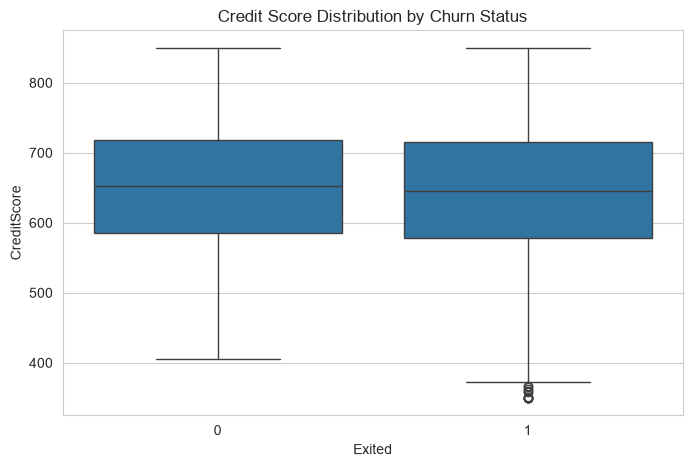

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.0,651.837855,95.650047,405.0,585.0,653.0,718.0,850.0
1,2038.0,645.414622,100.337351,350.0,578.0,646.0,716.0,850.0


In [17]:
#creditscore vs churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Exited', y='CreditScore', data=df_eda)
plt.title('Credit Score Distribution by Churn Status')
plt.show()
df_eda.groupby('Exited')['CreditScore'].describe()

Credit score shows no meaningful difference between churned and retained customers

Card Type
DIAMOND     21.779019
PLATINUM    20.360721
SILVER      20.112179
GOLD        19.264588
Name: Exited, dtype: float64


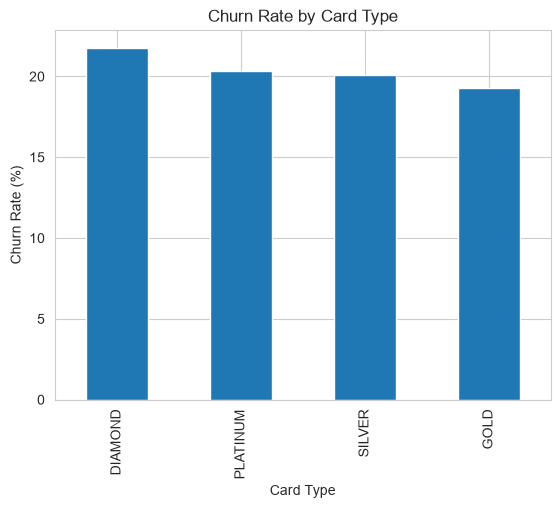

In [12]:
#cardtype vs churn
card_churn = df_eda.groupby('Card Type')['Exited'].mean().sort_values(ascending=False) * 100
print(card_churn)

card_churn.plot(kind='bar', title='Churn Rate by Card Type', ylabel='Churn Rate (%)')
plt.show()

All four card types sit within a 2.5 percentage point band of each other (19.3%–21.8%- no relevance of card type vs churn

Satisfaction Score
1    20.031056
2    21.797418
3    19.637610
4    20.617530
5    19.810379
Name: Exited, dtype: float64


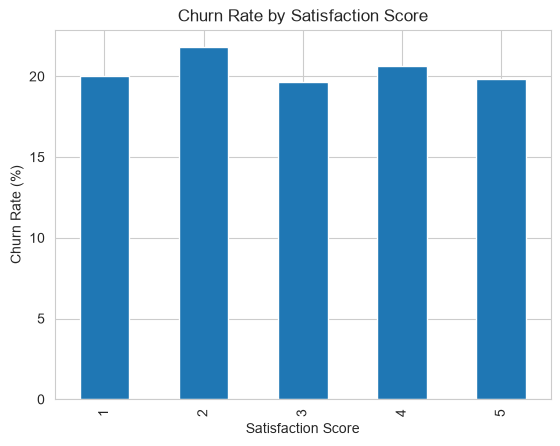

In [13]:
#Satisfactory score vs churn
sat_churn = df_eda.groupby('Satisfaction Score')['Exited'].mean() * 100
print(sat_churn)

sat_churn.plot(kind='bar', title='Churn Rate by Satisfaction Score', ylabel='Churn Rate (%)')
plt.show()

Churn rate is flat across all Satisfaction Score levels (19.6%–21.8%), showing no meaningful relationship.

In [14]:
#complain vs exited
crosstab = pd.crosstab(df_eda['Complain'], df_eda['Exited'])
print(crosstab)

complain_churn = df_eda.groupby('Complain')['Exited'].mean() * 100
print(complain_churn)

Exited       0     1
Complain            
0         7952     4
1           10  2034
Complain
0     0.050277
1    99.510763
Name: Exited, dtype: float64


Complain and Exited are almost perfectly aligned 99.5% of complainers churned, and 99.95% of non-complainers stayed. Only 14 out of 10,000 customers fall outside this pattern. This confirms Complain functions as a near-duplicate label of Exited, not an independent predictor, and must be excluded from any early-warning churn model, including it would let the model "cheat" by essentially looking at the answer. This is consistent with the data dictionary description of Satisfaction Score as a post-complaint metric, reinforcing that both fields represent information only available after the churn event has already begun, not before

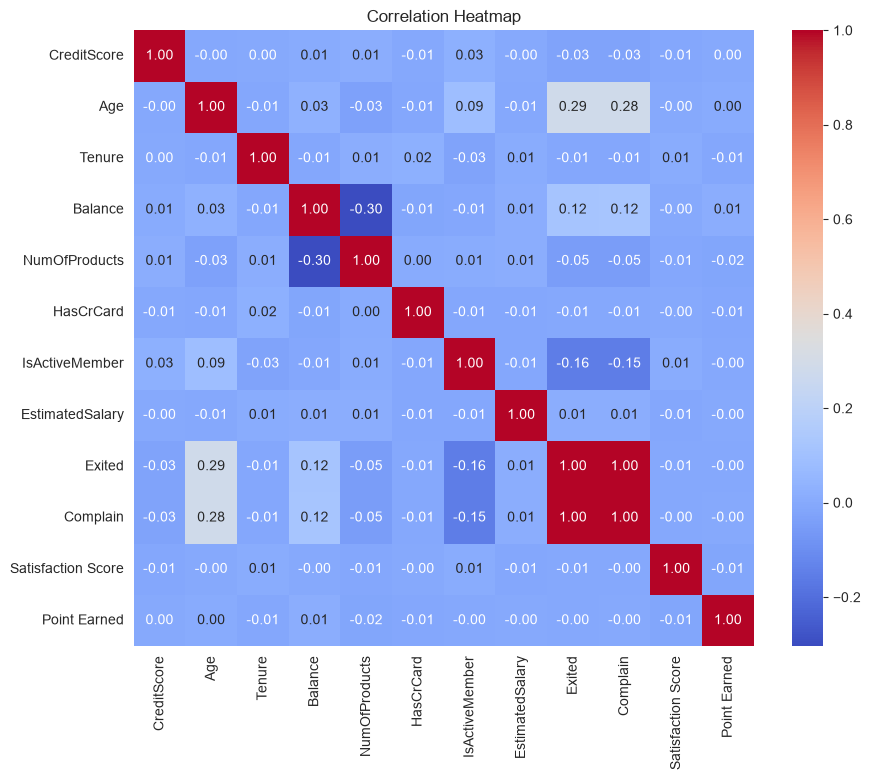

In [15]:
#correleation heatmap
plt.figure(figsize=(10,8))
numeric_cols = df_eda.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap confirms Complain (1.00) as near-total leakage, Age (0.29) as the strongest genuine linear churn driver, and IsActiveMember (-0.16) as a meaningful protective factor. Most other variables (CreditScore, Tenure, EstimatedSalary, Card-related fields) show negligible linear correlation, consistent with earlier findings. Notably, NumOfProducts appears weak here (-0.05) despite showing a strong non-linear (U-shaped) relationship with churn in the grouped bar chart — a reminder that correlation coefficients only capture linear patterns and can understate the importance of variables with non-linear effects.